In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
# --- 1. HÀM ĐỌC DỮ LIỆU CHUẨN ---
def parse_vrp_file(content):
    data = {}
    lines = [l.strip() for l in content.split('\n') if l.strip()]

    # Đọc Optimal value
    data['optimal_value'] = None
    for line in lines:
        if "COMMENT" in line:
            # Tìm kiếm mẫu "Optimal value:" theo sau là các chữ số
            match = re.search(r"Optimal value\s*:\s*(\d+)", line)
            if match:
                data['optimal_value'] = int(match.group(1))
            break
    
    # Đọc Capacity
    for line in lines:
        if "CAPACITY" in line:
            data['capacity'] = int(line.split(':')[-1])
            break
            
    # Đọc Tọa độ
    coord_start = lines.index("NODE_COORD_SECTION") + 1
    demands_start = lines.index("DEMAND_SECTION") + 1
    
    coords = []
    for i in range(coord_start, demands_start - 1):
        parts = lines[i].split()
        coords.append([float(parts[1]), float(parts[2])])
    
    # Đọc Nhu cầu
    demands = []
    for i in range(demands_start, lines.index("DEPOT_SECTION")):
        parts = lines[i].split()
        demands.append(int(parts[1]))
        
    data['coords'] = np.array(coords)
    data['demands'] = np.array(demands)
    return data

In [3]:
# --- 2. LỚP GIẢI TOÁN GA ---
class VRPSolverGA:
    def __init__(self, data, pop_size=100, gens=400):
        self.coords = data['coords']
        self.demands = data['demands']
        self.Q = data['capacity']
        self.pop_size = pop_size
        self.gens = gens
        self.n = len(self.demands)
        self.depot = self.coords[0]

    def fitness(self, tour):
        """Giải mã Giant Tour: Tách lộ trình khi vượt quá tải trọng Q """
        dist = 0
        load = 0
        curr_pos = self.depot
        
        for i in tour:
            d = self.demands[i]
            loc = self.coords[i]
            # Kiểm tra ràng buộc tải trọng 
            if load + d > self.Q:
                dist += np.linalg.norm(curr_pos - self.depot)
                dist += np.linalg.norm(self.depot - loc)
                load = d
            else:
                dist += np.linalg.norm(curr_pos - loc)
                load += d
            curr_pos = loc
            
        dist += np.linalg.norm(curr_pos - self.depot)
        return 1 / dist

    def run(self):
        customers = list(range(1, self.n))
        # Khởi tạo quần thể hoán vị [cite: 177]
        pop = [list(np.random.permutation(customers)) for _ in range(self.pop_size)]  # sinh ngẫu nhiên các cá thể
        history = []

        for g in range(self.gens):
            pop = sorted(pop, key=lambda x: self.fitness(x), reverse=True)
            best_dist = 1 / self.fitness(pop[0])
            history.append(best_dist)

            # Lai ghép OX và Đột biến hoán đổi 
            next_gen = pop[:5] # Giữ lại tinh hoa (Elitism)
            while len(next_gen) < self.pop_size:
                p1, p2 = [pop[i] for i in np.random.choice(len(pop[:20]), 2)]
                # Order Crossover (OX) 
                idx = np.random.randint(1, self.n-2)
                child = p1[:idx] + [x for x in p2 if x not in p1[:idx]]
                # Mutation 
                if np.random.rand() < 0.1:
                    a, b = np.random.choice(range(len(child)), 2)
                    child[a], child[b] = child[b], child[a]
                next_gen.append(child)
            pop = next_gen
            
        return pop[0], history

Kết quả tốt nhất tìm được: 962.88
Độ lệch so với tối ưu (784): 22.82%


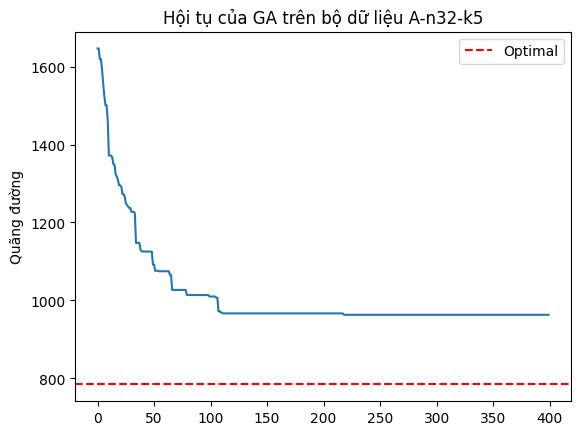

In [4]:
# --- 3. THỰC THI ---
file_path = "./Data/A-n32-k5.vrp"

# Mở và đọc nội dung file
with open(file_path, 'r') as f:
    file_content = f.read()

data = parse_vrp_file(file_content)
opt_val = data['optimal_value']

solver = VRPSolverGA(data)
best_tour, history = solver.run()

print(f"Kết quả tốt nhất tìm được: {history[-1]:.2f}")
print(f"Độ lệch so với tối ưu ({opt_val}): {((history[-1]-opt_val)/opt_val)*100:.2f}%")

plt.plot(history)
plt.axhline(y=opt_val, color='r', linestyle='--', label='Optimal')
plt.title("Hội tụ của GA trên bộ dữ liệu A-n32-k5")
plt.ylabel("Quãng đường")
plt.legend()
plt.show()